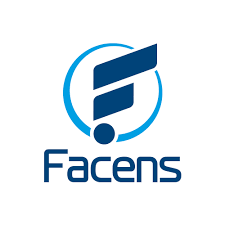
</p>

<br/>
  
<font size="3"><center>Prof. Julio Cesar Mastrodomenico</center></font>




# Aprendizado de Máquinas
### 2023PGS2M2
----

## <center> Máquina de Vetor de Suporte </center>

Implementação e utilização da Máquina de Vetor de Suporte ou Support Vector Machine

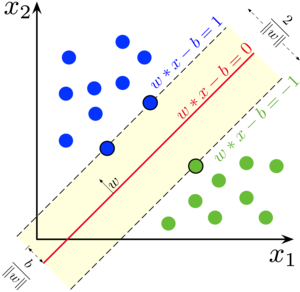

Banco de dados:
- Social Ads Network
- Iris
- Data3
- Digits
- Breast Cancer

### Exercícios

## 1) Importando as bibliotecas

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, \
                            f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import datasets
import random
from sklearn.pipeline import Pipeline
from glob import glob
from tqdm.notebook import tqdm

# Lib de hoje
from sklearn.decomposition import PCA

# Nossos Algoritmos
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.svm import SVC

In [8]:
!unzip /content/cat_n_dog_data.zip

Archive:  /content/cat_n_dog_data.zip
  inflating: train/cat.0.jpg         
  inflating: train/cat.1.jpg         
  inflating: train/cat.10.jpg        
  inflating: train/cat.100.jpg       
  inflating: train/cat.101.jpg       
  inflating: train/cat.102.jpg       
  inflating: train/cat.103.jpg       
  inflating: train/cat.104.jpg       
  inflating: train/cat.105.jpg       
  inflating: train/cat.106.jpg       
  inflating: train/cat.107.jpg       
  inflating: train/cat.108.jpg       
  inflating: train/cat.109.jpg       
  inflating: train/cat.11.jpg        
  inflating: train/cat.110.jpg       
  inflating: train/cat.111.jpg       
  inflating: train/cat.11193.jpg     
  inflating: train/cat.11194.jpg     
  inflating: train/cat.11195.jpg     
  inflating: train/cat.11196.jpg     
  inflating: train/cat.11197.jpg     
  inflating: train/cat.11198.jpg     
  inflating: train/cat.11199.jpg     
  inflating: train/cat.112.jpg       
  inflating: train/cat.11200.jpg     
  inflating:

## 2) Primeiro exercício e visualização da superfície de decisão
-----------------------

### Kernel Linear

In [ ]:
# Exercicio com o dataset 2D, Social Network Ads
dataset = pd.read_csv('/content/Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [ ]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[66  2]
 [ 8 24]]


0.9

### Visualização

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

### Kernel RBF

In [ ]:
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

In [ ]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[64  4]
 [ 3 29]]


0.93

### Visualização:

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Kernel SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Kernel SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

### Kernel Polinomial

In [ ]:
classifier = SVC(kernel = 'poly', random_state = 0)
classifier.fit(X_train, y_train)

SVC(kernel='poly', random_state=0)

In [ ]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[67  1]
 [13 19]]


0.86

### Visualização

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Kernel SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Kernel SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## 3) Iris Dataset

In [ ]:
# Importa o dataset do Iris direto do sklearn
loadiris = datasets.load_iris(as_frame=True)
df_iris = pd.concat((pd.DataFrame(loadiris.data),pd.DataFrame(loadiris.target)), axis=1)

print('Dados carregados com sucesso!')

Dados carregados com sucesso!


In [ ]:
# Visualizando nosso Dataset
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
df_iris['target'] = df_iris['target'].apply(lambda x: 1 if x == 1 or x == 2 else 0)

In [ ]:
df_iris['target'].value_counts()

,count
target,
1,100
0,50


In [ ]:
# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_iris.iloc[:, 0:-1].values

# pega os valores da última coluna e guarda em um vetor Y
Y = df_iris.iloc[:, -1].values

# imprime as 5 primeiras linhas da matriz X
print('X:', X[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

X: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Y: [0 0 0 0 0]


### Aplicando o PCA

In [ ]:
# Dividindo em Train Test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

In [ ]:
# Normalização dos dados por padronização
sc = StandardScaler()
X_norm = sc.fit_transform(X_train)
X_test_norm = sc.transform(X_test)


In [ ]:
# Aplicando o PCA
PCA_model = PCA(n_components=2)
X_train_pca = PCA_model.fit_transform(X_norm)
X_test_pca = PCA_model.transform(X_test_norm)


In [ ]:
# Instânciando nosso SVM
classifier = SVC()
classifier.fit(X_train_pca, y_train)


SVC()

In [ ]:
# Verificando a metrica
preds = classifier.predict(X_test_pca)
print(classification_report(y_test, preds))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        19

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Visualização dos Vetores de Suporte

In [ ]:
classifier.support_vectors_

array([[-1.89975402,  1.48441674],
       [-2.21530833,  2.79136822],
       [-1.97040472, -2.27744816],
       [-1.85640514,  0.15796756],
       [-2.01157946, -0.55203824],
       [ 0.38438741,  0.82574988],
       [-0.55395597, -1.53996494],
       [ 3.18283956, -0.14772524],
       [-0.60016248, -1.84510592],
       [ 2.27395807,  2.52248505]])

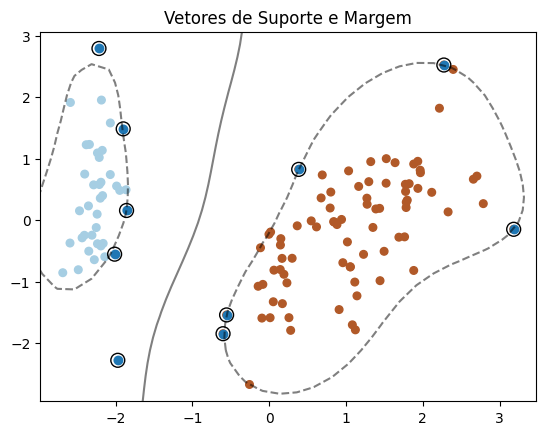

In [ ]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, cmap=plt.cm.Paired)
plt.scatter(classifier.support_vectors_[:,0],classifier.support_vectors_[:,1])

# PLot da função de decisão
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Grid para visualizar as margens
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = classifier.decision_function(xy).reshape(XX.shape)

# Plot das margens e decision boundary
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
# Plot dos vetores de suporte
ax.scatter(classifier.support_vectors_[:, 0], classifier.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k')
plt.title('Vetores de Suporte e Margem')
plt.show()

In [ ]:
# Realizar a mesma visualização com diferentes kernels
classifier = SVC(kernel='linear', C=0.01)
classifier.fit(X_train_pca, y_train)

SVC(C=0.01, kernel='linear')

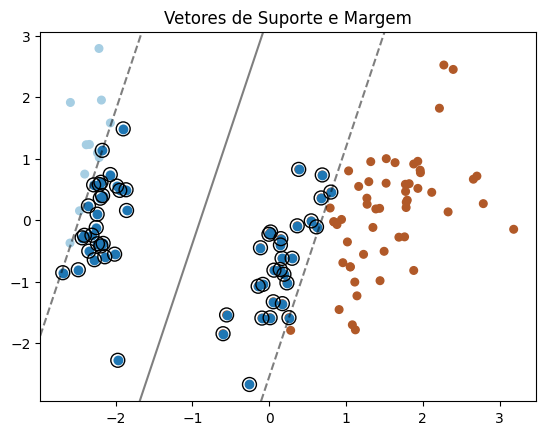

In [ ]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, cmap=plt.cm.Paired)
plt.scatter(classifier.support_vectors_[:,0],classifier.support_vectors_[:,1])

# PLot da função de decisão
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Grid para visualizar as margens
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = classifier.decision_function(xy).reshape(XX.shape)

# Plot das margens e decision boundary
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
# Plot dos vetores de suporte
ax.scatter(classifier.support_vectors_[:, 0], classifier.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k')
plt.title('Vetores de Suporte e Margem')
plt.show()

In [ ]:
classifier = SVC(kernel='poly', C=15)
classifier.fit(X_train_pca, y_train)

SVC(C=15, kernel='poly')

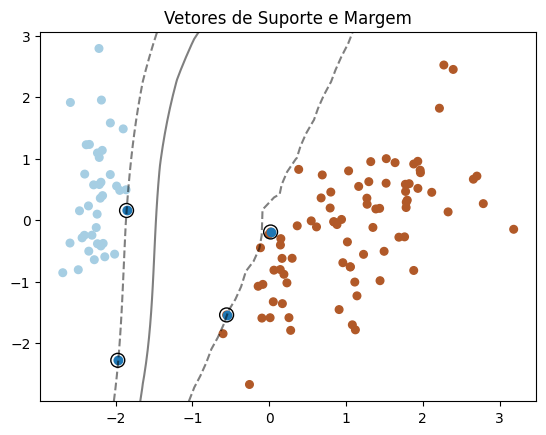

In [ ]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, cmap=plt.cm.Paired)
plt.scatter(classifier.support_vectors_[:,0],classifier.support_vectors_[:,1])

# PLot da função de decisão
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Grid para visualizar as margens
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = classifier.decision_function(xy).reshape(XX.shape)

# Plot das margens e decision boundary
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
# Plot dos vetores de suporte
ax.scatter(classifier.support_vectors_[:, 0], classifier.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k')
plt.title('Vetores de Suporte e Margem')
plt.show()

In [ ]:
classifier = SVC(kernel='rbf', C=15)
classifier.fit(X_train_pca, y_train)

SVC(C=15)

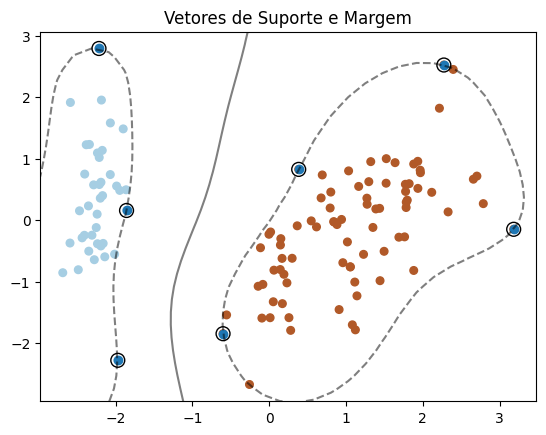

In [ ]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, cmap=plt.cm.Paired)
plt.scatter(classifier.support_vectors_[:,0],classifier.support_vectors_[:,1])

# PLot da função de decisão
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Grid para visualizar as margens
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = classifier.decision_function(xy).reshape(XX.shape)

# Plot das margens e decision boundary
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
# Plot dos vetores de suporte
ax.scatter(classifier.support_vectors_[:, 0], classifier.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k')
plt.title('Vetores de Suporte e Margem')
plt.show()

### Grid Search

* Linear - Param C
* RBF - Param Gamma
* Poly - Param Degree

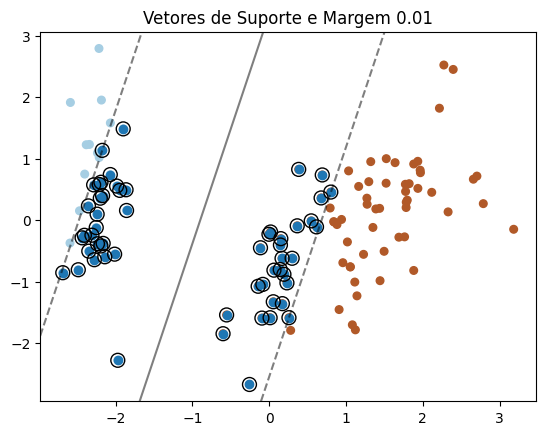

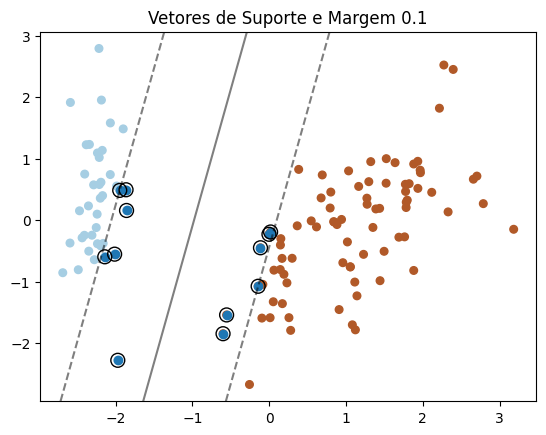

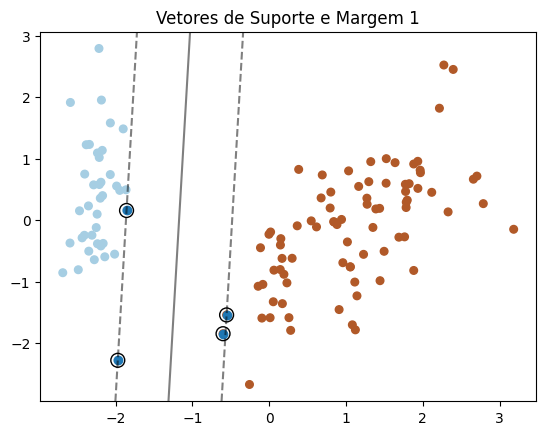

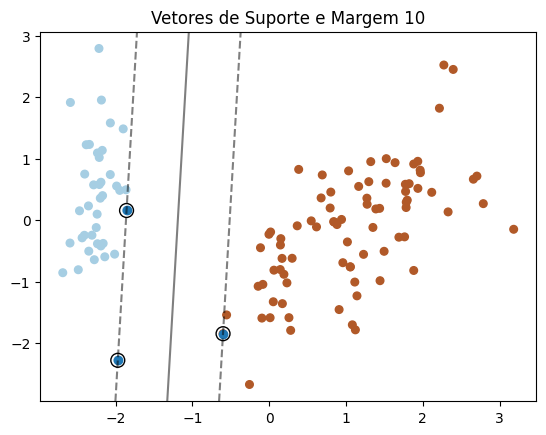

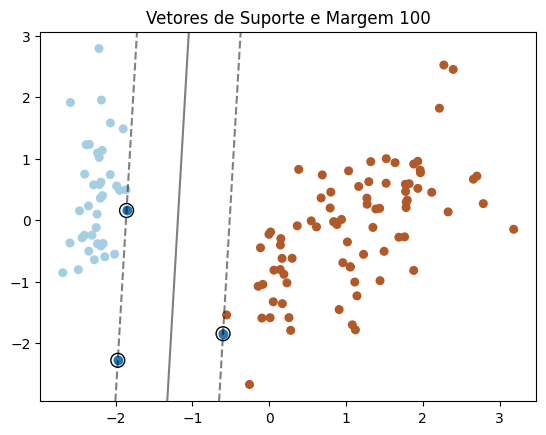

In [ ]:
# Um meio de se testar os parametros
C_range = [0.01, 0.1, 1, 10, 100]
acc_score = []
for c in C_range:
    svc = SVC(kernel='linear', C=c).fit(X_train_pca, y_train)
    acc_score.append([c, svc.score(X_test_pca, y_test)])
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, cmap=plt.cm.Paired)
    plt.scatter(svc.support_vectors_[:,0],svc.support_vectors_[:,1])

    # PLot da função de decisão
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Grid para visualizar as margens
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = svc.decision_function(xy).reshape(XX.shape)

    # Plot das margens e decision boundary
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # Plot dos vetores de suporte
    ax.scatter(svc.support_vectors_[:, 0], svc.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')
    plt.title('Vetores de Suporte e Margem ' + str(c))
    plt.show()

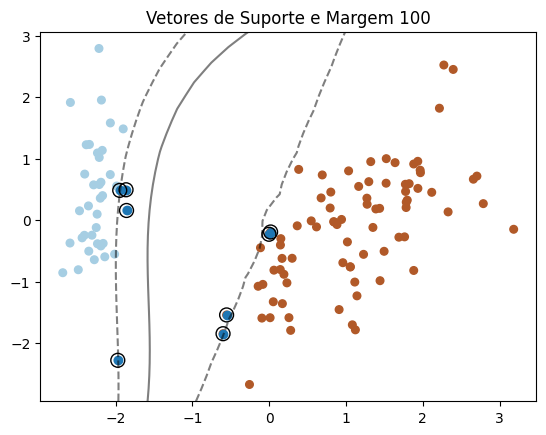

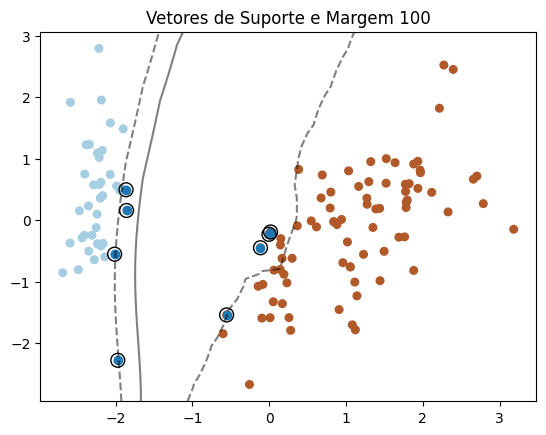

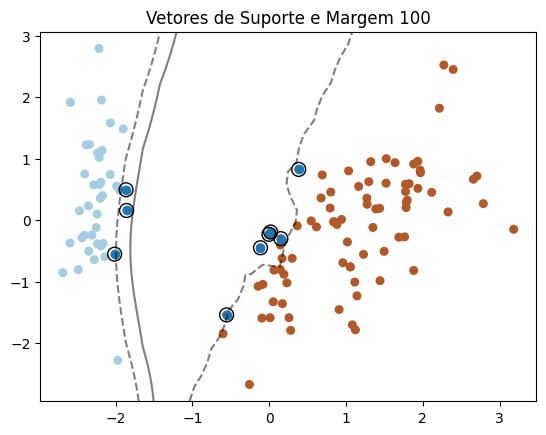

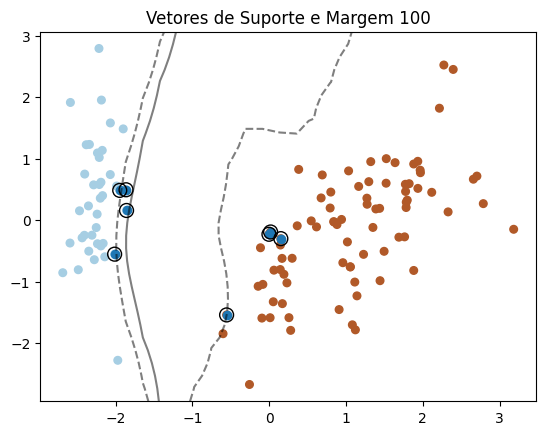

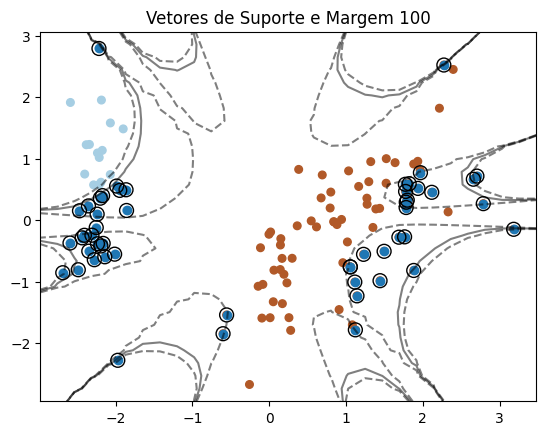

In [ ]:
# Um meio de se testar os parametros
degree = [3, 5, 7, 9, 12]
acc_score = []
for d in degree:
    svc = SVC(kernel='poly', degree=d).fit(X_train_pca, y_train)
    acc_score.append([c, svc.score(X_test_pca, y_test)])
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, s=30, cmap=plt.cm.Paired)
    plt.scatter(svc.support_vectors_[:,0],svc.support_vectors_[:,1])

    # PLot da função de decisão
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Grid para visualizar as margens
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = svc.decision_function(xy).reshape(XX.shape)

    # Plot das margens e decision boundary
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # Plot dos vetores de suporte
    ax.scatter(svc.support_vectors_[:, 0], svc.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')
    plt.title('Vetores de Suporte e Margem ' + str(c))
    plt.show()

In [ ]:
acc_score

[[100, 1.0], [100, 1.0], [100, 1.0], [100, 1.0], [100, 0.8333333333333334]]

In [ ]:
# Verificar a separação com diferentes parâmetros de degrees para polinômio e gamma para o RBF


### Agora com Grid Search do Sklearn

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Defini-se os ranges dos parametros
param_grid = {'C': [0.1, 1, 10, 100],
              'degree': [3, 5],
              'gamma': [0.1, 1, 10, 100],
              'kernel': ['rbf', 'poly']
}


In [ ]:
# Instancia o GridSearch com o classificador
grid_svm = GridSearchCV(SVC(), param_grid, verbose = 3)

In [ ]:
# Faz-se o fit
grid_svm.fit(X_train_pca, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 3/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 4/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 5/5] END C=0.1, degree=3, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/5] END C=0.1, degree=3, gamma=0.1, kernel=poly;, score=0.708 total time=   0.0s
[CV 2/5] END C=0.1, degree=3, gamma=0.1, kernel=poly;, score=0.708 total time=   0.0s
[CV 3/5] END C=0.1, degree=3, gamma=0.1, kernel=poly;, score=0.667 total time=   0.0s
[CV 4/5] END C=0.1, degree=3, gamma=0.1, kernel=poly;, score=0.708 total time=   0.0s
[CV 5/5] END C=0.1, degree=3, gamma=0.1, kernel=poly;, score=0.667 total time=   0.0s
[CV 1/5] END C=0.1, degree=3, gamma=1, kernel=rbf;, score=1.000 total time=   0.0s


GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'degree': [3, 5],
                         'gamma': [0.1, 1, 10, 100],
                         'kernel': ['rbf', 'poly']},
             verbose=3)

In [ ]:
# Visualizando os melhores parametros depois do tunning
grid_svm.best_estimator_

SVC(C=0.1, gamma=0.1)

In [ ]:
# Visualizando o modelo depois do tunning de hiper parametro
grid_svm.predict(X_test_pca)


array([1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0])

In [ ]:
grid_svm.best_params_

{'C': 0.1, 'degree': 3, 'gamma': 0.1, 'kernel': 'rbf'}

In [ ]:
grid_svm.best_score_

1.0

## Visualizando a superfície de decisão dos diversos kernels

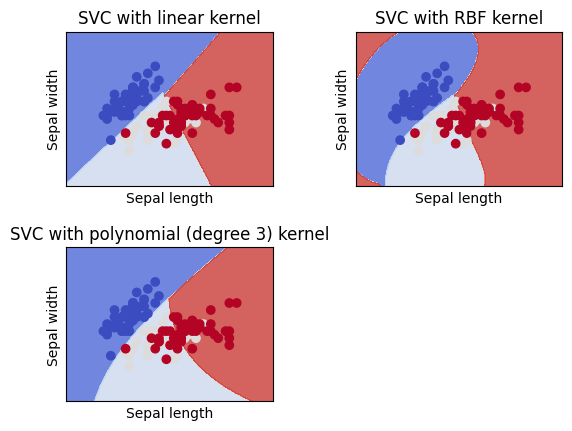

In [ ]:
# import some data to play with
iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features. We could
                      # avoid this ugly slicing by using a two-dim dataset
y = iris.target

h = .02  # step size in the mesh

# we create an instance of SVM and fit out data. We do not scale our
# data since we want to plot the support vectors
C = 1.0  # SVM regularization parameter
svc = SVC(kernel='linear', C=C).fit(X, y)
rbf_svc = SVC(kernel='rbf', gamma=0.7, C=C).fit(X, y)
poly_svc = SVC(kernel='poly', degree=3, C=C).fit(X, y)

# create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# title for the plots
titles = ['SVC with linear kernel',
          'SVC with RBF kernel',
          'SVC with polynomial (degree 3) kernel']


for i, clf in enumerate((svc, rbf_svc, poly_svc)):
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    plt.subplot(2, 2, i + 1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

plt.show()

### KFold e Cross Val Score

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
loadiris = datasets.load_iris(as_frame=True)
df_iris = pd.concat((pd.DataFrame(loadiris.data),pd.DataFrame(loadiris.target)), axis=1)

# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_iris.iloc[:, 0:-1].values

# pega os valores da última coluna e guarda em um vetor Y
y = df_iris.iloc[:, -1].values

In [ ]:
# Instanciando nosso KFold
kf = KFold(n_splits=5, shuffle=True)

In [ ]:
# Iterando dentro dos splits
kfold_scores = []
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    print(len(X_train), len(X_test))
    svm = SVC()
    svm.fit(X_train, y_train)
    kfold_scores.append(svm.score(X_test, y_test))

120 30
120 30
120 30
120 30
120 30


In [ ]:
# Visualizando nosso resultado
kfold_scores


[1.0, 0.9666666666666667, 0.9, 0.9666666666666667, 0.9666666666666667]

In [ ]:
# Pegando a média
np.array(kfold_scores).mean()

0.96

In [ ]:
# Realizando a mesma tarefa agora com cross_val_score
scores = cross_val_score(SVC(), X, y, cv=10, scoring ='f1_weighted')

In [ ]:
# Scores
scores


array([1.        , 0.93265993, 1.        , 1.        , 1.        ,
       0.93265993, 0.93265993, 0.93265993, 1.        , 1.        ])

In [ ]:
# Scores média
scores.mean()


0.973063973063973

## Exercício com o Dataset data3

In [ ]:
# Importando o dataset
df_3 = pd.read_csv('/content/data3.csv', names=['FT1', 'FT2', 'Target'])

In [ ]:
df_3

,FT1,FT2,Target
0,-0.158986,0.423977,1
1,-0.347926,0.470760,1
2,-0.504608,0.353801,1
3,-0.596774,0.114035,1
4,-0.518433,-0.172515,1
...,...,...,...
206,-0.399885,-0.621930,1
207,-0.124078,-0.126608,1
208,-0.316935,-0.228947,1
209,-0.294124,-0.134795,0


In [ ]:
# Targets
df_3['Target'].value_counts()

,count
Target,
1,106
0,105


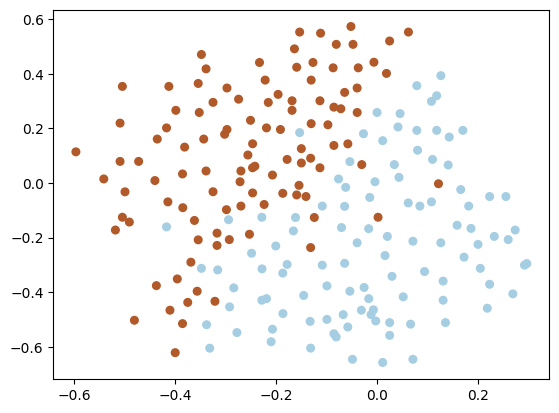

In [ ]:
# Plot dos dados
plt.scatter(df_3.iloc[:, 0], df_3.iloc[:, 1], c=df_3.iloc[:,-1], s=30, cmap=plt.cm.Paired)
plt.show()


In [ ]:
# Parametros
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': [0.1, 1, 10, 100],
              'kernel': ['rbf', 'linear']
}

In [ ]:
grid_svm = GridSearchCV(SVC(), param_grid, verbose = 3, cv=10)

In [ ]:
X = df_3.iloc[:, 0:-1].values
y = df_3.iloc[:, -1].values

In [ ]:
grid_svm.fit(X, y)

Fitting 10 folds for each of 32 candidates, totalling 320 fits
[CV 1/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.500 total time=   0.0s
[CV 2/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.762 total time=   0.0s
[CV 3/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.905 total time=   0.0s
[CV 4/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 5/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 6/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.952 total time=   0.0s
[CV 7/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.476 total time=   0.0s
[CV 8/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.476 total time=   0.0s
[CV 9/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.476 total time=   0.0s
[CV 10/10] END ....C=0.1, gamma=0.1, kernel=rbf;, score=0.476 total time=   0.0s
[CV 1/10] END ..C=0.1, gamma=0.1, kernel=linear;, score=1.000 total time=   0.0s
[CV 2/10] END ..C=0.1, gamma=0.1, kernel=linea

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.1, 1, 10, 100],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [ ]:
grid_svm.best_estimator_

SVC(C=1, gamma=10)

In [ ]:
grid_svm.best_params_

{'C': 1, 'gamma': 10, 'kernel': 'rbf'}

In [ ]:
grid_svm.best_score_

0.9190476190476191

In [ ]:
scores = cross_val_score(SVC(), X, y, cv=10, scoring ='f1_weighted')

In [ ]:
scores

array([1.        , 0.80952381, 0.85648905, 1.        , 1.        ,
       0.95238095, 0.95238095, 0.8042328 , 1.        , 0.80952381])

In [ ]:
scores.mean()

0.9184531376751057

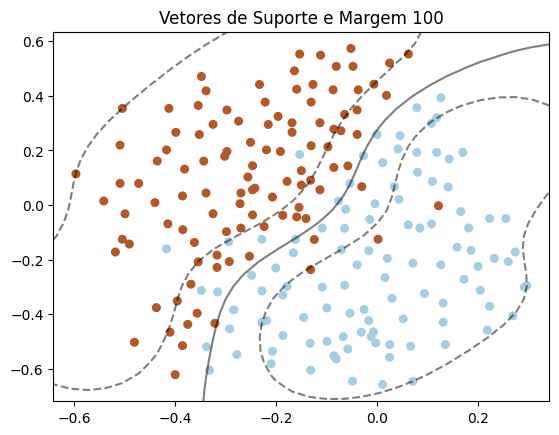

In [ ]:
# Plot da superfície de divisão
plt.scatter(df_3.iloc[:, 0], df_3.iloc[:, 1], c=df_3.iloc[:,-1], s=30, cmap=plt.cm.Paired)

# PLot da função de decisão
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Grid para visualizar as margens
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Aqui colocar seu classificador
Z = grid_svm.decision_function(xy).reshape(XX.shape)

# Plot das margens e decision boundary
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
plt.title('Vetores de Suporte e Margem ' + str(c))
plt.show()

In [ ]:
# data3_val
df_3_val = pd.read_csv('/content/data3_val.csv', names=['FT1', 'FT2', 'Target'])

In [ ]:
df_3_val

,FT1,FT2,Target
0,-0.353062,-0.673902,0
1,-0.227126,0.447320,1
2,0.092898,-0.753524,0
3,0.148243,-0.718473,0
4,-0.001512,0.162928,0
...,...,...,...
195,0.005203,-0.544449,1
196,0.176352,-0.572454,0
197,0.127651,-0.340938,0
198,0.248682,-0.497502,0


In [ ]:
# Verificando a metrica
y_pred = grid_svm.predict(df_3_val.iloc[:, 0:-1].values)
print(classification_report(df_3_val.iloc[:, -1].values, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       113
           1       0.92      0.97      0.94        87

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



## Exercício dataset Wine ( direto do sklearn )

$ from sklearn import datasets

$ wine = datasets.load_wine()

In [ ]:
# Carregando o dataset
wine = datasets.load_wine(as_frame=True)

In [ ]:
wine.data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [ ]:
X = wine.data
y = wine.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [ ]:
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': [0.1, 1, 10, 100],
              'kernel': ['rbf', 'linear']
}

In [ ]:
grid_svm = GridSearchCV(SVC(), param_grid, verbose = 3, cv=10)

In [ ]:
# Normalizar

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)



In [ ]:
svm_grid = grid_svm.fit(X_train_norm, y_train)

Fitting 10 folds for each of 32 candidates, totalling 320 fits
[CV 1/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 3/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 4/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 5/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 6/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 7/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 8/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 9/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 10/10] END ....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/10] END ..C=0.1, gamma=0.1, kernel=linear;, score=0.938 total time=   0.0s
[CV 2/10] END ..C=0.1, gamma=0.1, kernel=linea

In [ ]:
svm_estimator = grid_svm.best_estimator_
svm_estimator

SVC(C=1, gamma=0.1)

In [ ]:
svm_params = grid_svm.best_params_
svm_params

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

In [ ]:
svm_score = grid_svm.best_score_
svm_score

0.9875

In [ ]:
# PCA
pca = PCA(n_components=0.85)
X_train_pca = pca.fit_transform(X_train_norm)
X_test_pca = pca.transform(X_test_norm)

In [ ]:
pca_grid = grid_svm.fit(X_train_pca, y_train)

Fitting 10 folds for each of 32 candidates, totalling 320 fits
[CV 1/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 3/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 4/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 5/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 6/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 7/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 8/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 9/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 10/10] END ....C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/10] END ..C=0.1, gamma=0.1, kernel=linear;, score=0.938 total time=   0.0s
[CV 2/10] END ..C=0.1, gamma=0.1, kernel=linea

In [ ]:
pca_estimator = grid_svm.best_estimator_
pca_estimator

SVC(C=1, gamma=0.1)

In [ ]:
pca_params = grid_svm.best_params_
pca_params

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

In [ ]:
pca_score = grid_svm.best_score_
pca_score

0.98125

In [ ]:
print(classification_report(y_test, pca_estimator.predict(X_test_pca)))
print(classification_report(y_test, svm_estimator.predict(X_test_norm)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



In [ ]:
# Testar métricas



array([[7, 0, 0],
       [0, 5, 0],
       [0, 1, 5]])

In [ ]:
# Verificando a metrica


## Dataset Dígitos

In [ ]:
# Carregando o dataset de dígitos
d_digits = datasets.load_digits(as_frame=True)

In [ ]:
d_digits

{'data':       pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
 0           0.0        0.0        5.0       13.0        9.0        1.0   
 1           0.0        0.0        0.0       12.0       13.0        5.0   
 2           0.0        0.0        0.0        4.0       15.0       12.0   
 3           0.0        0.0        7.0       15.0       13.0        1.0   
 4           0.0        0.0        0.0        1.0       11.0        0.0   
 ...         ...        ...        ...        ...        ...        ...   
 1792        0.0        0.0        4.0       10.0       13.0        6.0   
 1793        0.0        0.0        6.0       16.0       13.0       11.0   
 1794        0.0        0.0        1.0       11.0       15.0        1.0   
 1795        0.0        0.0        2.0       10.0        7.0        0.0   
 1796        0.0        0.0       10.0       14.0        8.0        1.0   
 
       pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
 0        

In [ ]:
df = pd.DataFrame(d_digits.data)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
# Visualização dos dados
im = df.iloc[39,:].values

In [ ]:
im_r = im.reshape(8,8)

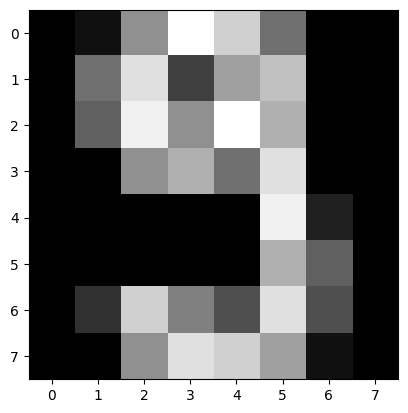

In [ ]:
plt.imshow(im_r, cmap='gray')

In [ ]:
d_digits.images.shape

(1797, 8, 8)

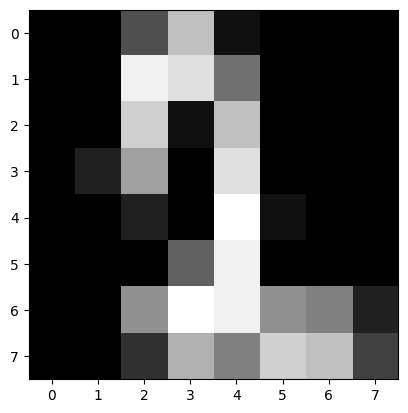

In [ ]:
plt.imshow(d_digits.images[12], cmap='gray')

In [ ]:
df['target'] = d_digits.target

In [ ]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [ ]:
# Predict sem PCA
X_train, X_test, y_train, y_test = train_test_split(df.drop('target',axis='columns'), df.target, test_size=0.2, random_state=42)

In [ ]:
#normalizar
sc = StandardScaler()
X_train_norm = sc.fit_transform(X_train)


In [ ]:
grid_svm = GridSearchCV(SVC(), param_grid, verbose = 3, cv=10)

In [ ]:
svm_grid = grid_svm.fit(X_train_norm, y_train)

Fitting 10 folds for each of 32 candidates, totalling 320 fits
[CV 1/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.347 total time=   0.3s
[CV 2/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.444 total time=   0.3s
[CV 3/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.396 total time=   0.3s
[CV 4/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.354 total time=   0.3s
[CV 5/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.382 total time=   0.3s
[CV 6/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.424 total time=   0.3s
[CV 7/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.382 total time=   0.3s
[CV 8/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.336 total time=   0.3s
[CV 9/10] END .....C=0.1, gamma=0.1, kernel=rbf;, score=0.350 total time=   0.3s
[CV 10/10] END ....C=0.1, gamma=0.1, kernel=rbf;, score=0.378 total time=   0.3s
[CV 1/10] END ..C=0.1, gamma=0.1, kernel=linear;, score=0.993 total time=   0.0s
[CV 2/10] END ..C=0.1, gamma=0.1, kernel=linea

In [ ]:
grid_svm.best_estimator_

SVC(C=0.1, gamma=0.1, kernel='linear')

In [ ]:
grid_svm.best_params_

{'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}

In [ ]:
grid_svm.best_score_

0.9777146464646466

In [ ]:
print(classification_report(y_test, grid_svm.predict(sc.transform(X_test))))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       1.00      0.90      0.95        30
           9       0.95      0.97      0.96        40

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



## Exercício de classificação de imagens

In [2]:
# Lendo o Dataset
files_glob = glob('/content/train/*.jpg')

In [3]:
len(files_glob)

800

In [3]:
# Utilizando uma CNN para extrair as características das imagens, vamos carregar o modelo
import torch
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
from PIL import Image

In [4]:
from torchvision.models.resnet import ResNet18_Weights

In [5]:
pre_trained = models.resnet18(weights=ResNet18_Weights.DEFAULT)

In [7]:
pre_trained

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
# Transformando a imagem em um tensor
feat_extractor = nn.Sequential(*list(pre_trained.children())[:-1])

In [9]:
feat_extractor

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [11]:
device

'cuda'

In [8]:
feat_extractor.to(device)
feat_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

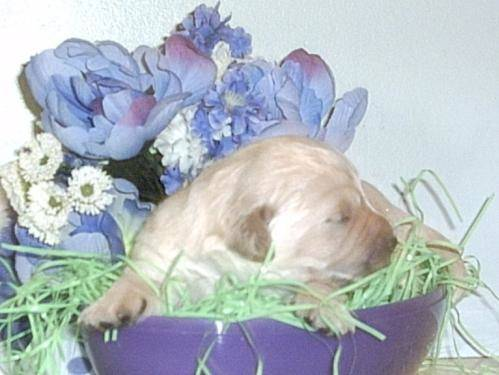

In [9]:
im = Image.open(files_glob[459])
im

In [10]:
np.array(im).shape

(375, 499, 3)

In [11]:
transform_image = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224,224)),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    )
])

In [12]:
im_trans = transform_image(im)


In [17]:
im_trans.size()

torch.Size([3, 224, 224])

In [18]:
im_trans

tensor([[[2.2257, 2.2292, 2.2055,  ..., 1.3917, 1.4028, 1.3927],
         [2.2008, 2.2091, 2.1789,  ..., 1.3643, 1.3855, 1.3927],
         [2.1860, 2.1943, 2.1642,  ..., 1.3893, 1.4031, 1.3927],
         ...,
         [1.3573, 1.0351, 1.1220,  ..., 1.1199, 1.2648, 1.2191],
         [1.7164, 1.1661, 0.8712,  ..., 0.9702, 1.0069, 1.0881],
         [1.9772, 1.4681, 0.8910,  ..., 1.3679, 1.2525, 1.1179]],

        [[2.4224, 2.4259, 2.4017,  ..., 1.7098, 1.7198, 1.6967],
         [2.3969, 2.4053, 2.3745,  ..., 1.6817, 1.7021, 1.6967],
         [2.3818, 2.3903, 2.3594,  ..., 1.7073, 1.7210, 1.7056],
         ...,
         [1.7165, 1.4245, 1.5690,  ..., 1.4545, 1.5733, 1.5756],
         [2.0836, 1.5584, 1.3127,  ..., 1.3011, 1.3065, 1.4417],
         [2.3391, 1.8673, 1.3329,  ..., 1.7069, 1.5439, 1.4482]],

        [[2.6400, 2.6400, 2.6365,  ..., 2.0127, 2.0635, 2.0963],
         [2.6368, 2.6386, 2.6196,  ..., 1.9847, 2.0459, 2.0963],
         [2.6278, 2.6351, 2.6060,  ..., 2.0101, 2.0598, 2.

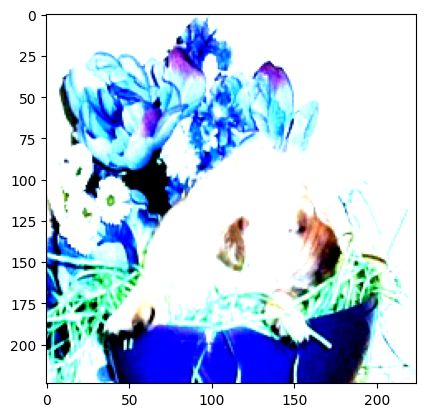

In [19]:
plt.imshow(im_trans.permute(1,2,0))

In [14]:
# Extraindo as caracteristicas da imagem
with torch.no_grad():
  arr = feat_extractor(im_trans.unsqueeze(0).to(device))

In [21]:
arr.size()

torch.Size([1, 512, 1, 1])

In [15]:
arr = torch.reshape(arr, (1, 512))

In [23]:
arr.size()

torch.Size([1, 512])

In [16]:
files_glob[10].split('/')[-1].split('.')[0]

'dog'

In [17]:
if 'dog' in files_glob[322]:
  print('dog')
else:
  print('cat')

dog


In [22]:
# Gerar dataset

df_list = list()

for im in tqdm(files_glob):
  if 'dog' in im:
    label = 1
  else:
    label = 0

  img = Image.open(im)
  img_t = transform_image(img)
  with torch.no_grad():
    arr = feat_extractor(img_t.unsqueeze(0).to(device))

  arr = torch.reshape(arr, (1, 512))

  df_list.append({
      'image': im.split('/')[-1],
      'target': label,
      'features': arr
  })

df_imgs = pd.DataFrame(df_list)

  0%|          | 0/800 [00:00<?, ?it/s]

In [24]:
X = [x.tolist()[0] for x in df_imgs.features.values]
X = np.array(X)
X.shape

(800, 512)

In [23]:
y = df_imgs.target.values


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [27]:
svc = SVC()
svc.fit(X_train, y_train)

SVC()

In [28]:
preds = svc.predict(X_test)

In [29]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        81
           1       0.99      0.99      0.99        79

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [ ]:
# Fazer uma série de predicts no teste para verificar com o resultado
# Recomendação, trabalhar a saída para colocar uma string em vez de int ( Gato ou Cachorro )


In [30]:
# Lendo o Dataset
files_glob = glob('/content/val/*.jpg')

In [31]:
len(files_glob)

200

In [ ]:
#Para 10 iterações dentro do files val
#Pegar um arquivo aleatorio dentro do files val
#tratar para virar input do svm
#print(A IA falou que é gato/cachorro)

In [43]:

# Para 10 iterações dentro do files val
for i in range(10):
  # Pegar um arquivo aleatorio dentro do files val
  choice = np.random.choice(files_glob)

  #Processamento da iamgem
  img = Image.open(choice)
  img_t = transform_image(img)
  with torch.no_grad():
    arr = feat_extractor(img_t.unsqueeze(0).to(device))
  arr = torch.reshape(arr, (1, 512))

  # Fazer o predict
  pred = svc.predict(arr.detach().cpu().numpy())

  plt.imshow(img)
  plt.show()

  if pred == 1:
    print('Cachorro')
  else:
    print('Gato')

Output hidden; open in https://colab.research.google.com to view.

In [44]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        81
           1       0.99      0.99      0.99        79

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



In [ ]:
#tratar para virar input do svm



## Exercício com o dataset Breast Câncer do Sklearn